# FOV exemplars

Reproduces the **field-of-view (FOV) exemplar** panels of the DeepCell Types
paper — raw multiplex-imaging FOVs rendered as per-cell colored maps.

Panels, in order:

- **FOV exemplars across modalities (Fig. 3b)** — a 2x3 grid of test-split FOVs
  spanning imaging modalities/tissues, every cell colored by its DCT-predicted
  cell type with mispredictions outlined + cross-hatched (per-FOV macro F1 chip).
- **Workflow comparison (Supp. Fig. 8b)** — one exemplar FOV (Sorin LUAD D119
  IMC) rendered three ways: the traditional mean-intensity + KMeans +
  rule-based-expert workflow, the DeepCell Types prediction, and the ground truth.

> These panels read **raw FOV images / segmentation masks from the
> expanded-TissueNet zarr archive** (`paths.EXPANDED_TISSUENET_ZARR`; public
> users set `DATA_DIR` after downloading the release archive). They load full
> FOV masks (and, for the workflow panel, the full raw channel stack + KMeans
> overclustering), so these cells are **slow to execute** (minutes).

All figures use a consistent publication figure style via `dct_figures.style`;
per-cell colors use the colorblind-safe lineage palette in `dct_figures.colors`.
Predictions come from the released From Scratch prediction CSVs — no model
inference runs in this notebook.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd()))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from dct_figures import paths, style, colors, scoring
style.apply_style()

## Shared inputs and helpers

The FOV panels read predictions from the released CSVs under `paths.OUTPUT`
and raw images/masks from the expanded-TissueNet zarr archive. The cell below
defines three pure-numpy/matplotlib helpers (best-square-crop, error-overlay
drawing, and the colorblind-safe `celltype_color_mapping`) plus a tiny config
object that supplies the `lineage_mapping` / `zarr_path` / `dataset_keys` the
selection and coloring code expects.

In [2]:
import os, json, yaml
import matplotlib
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from collections import Counter, defaultdict
from scipy.ndimage import binary_dilation
import zarr

from dct_figures.style import (PAL, COL_2, COL_1,
    FS_TICK, is_narrow_figure)
from dct_figures.colors import celltype_color_mapping, LINEAGE_ANCHORS

# --- input paths (all under data/, populated by the data-copy step) ---
ZARR = str(paths.EXPANDED_TISSUENET_ZARR)
TEST_PRED_CSV = paths.OUTPUT / 'deepcelltypes_test_prediction.csv'
for p in (TEST_PRED_CSV,):
    paths.need(p)
paths.need(pathlib.Path(ZARR))
print('FOV inputs present; zarr =', paths.EXPANDED_TISSUENET_ZARR.name)


# --- config object (lineage_mapping / zarr_path / dataset_keys) ---------
class _Config:
    # Supplies just the attributes the FOV-selection + coloring code uses.
    def __init__(self, zarr_path):
        self.zarr_path = str(zarr_path)
        self.lineage_mapping = yaml.safe_load(
            open(paths.DATA_ROOT / 'lineage_mapping.yaml'))
        self._keys = None
    @property
    def dataset_keys(self):
        if self._keys is None:
            self._keys = list(zarr.open(self.zarr_path, mode='r').group_keys())
        return self._keys

CONFIG = _Config(ZARR)


# --- best_square_crop helper --------------------------------------------
def best_square_crop(density, side, stride=None):
    H, W = density.shape
    side_h = min(side, H); side_w = min(side, W)
    if H <= side_h and W <= side_w:
        return 0, 0, side_h, side_w
    if stride is None:
        stride = max(1, min(side_h, side_w) // 8)
    cs = np.cumsum(np.cumsum(density.astype(np.int32), axis=0), axis=1)
    def _wsum(r, c):
        r2 = r + side_h - 1; c2 = c + side_w - 1
        s = cs[r2, c2]
        if r > 0: s -= cs[r - 1, c2]
        if c > 0: s -= cs[r2, c - 1]
        if r > 0 and c > 0: s += cs[r - 1, c - 1]
        return s
    best_sum = -1; best_rc = (0, 0)
    for r in range(0, H - side_h + 1, stride):
        for c in range(0, W - side_w + 1, stride):
            v = _wsum(r, c)
            if v > best_sum:
                best_sum = v; best_rc = (r, c)
    return best_rc[0], best_rc[1], side_h, side_w


# --- draw_error_overlay helper ------------------------------------------
def draw_error_overlay(ax, sub_mask, err_cell_ids, *, outline=True, hatch=True,
                       outline_zorder=5.0, hatch_zorder=4.5):
    if err_cell_ids is None:
        return
    err_ids = np.asarray(list(err_cell_ids), dtype=sub_mask.dtype)
    if err_ids.size == 0:
        return
    err_mask = np.isin(sub_mask, err_ids)
    if not err_mask.any():
        return
    H_, W_ = sub_mask.shape
    extent = (-0.5, W_ - 0.5, H_ - 0.5, -0.5)
    if outline:
        edge = np.zeros_like(err_mask)
        edge[:, :-1] |= err_mask[:, :-1] & ~err_mask[:, 1:]
        edge[:, 1:]  |= err_mask[:, 1:]  & ~err_mask[:, :-1]
        edge[:-1, :] |= err_mask[:-1, :] & ~err_mask[1:, :]
        edge[1:, :]  |= err_mask[1:, :]  & ~err_mask[:-1, :]
        edge = binary_dilation(edge)
        overlay = np.zeros((H_, W_, 4), dtype=float)
        overlay[edge] = (0.0, 0.0, 0.0, 1.0)
        ax.imshow(overlay, interpolation='nearest', aspect='equal',
                  extent=extent, zorder=outline_zorder)
    if hatch:
        xs = np.arange(W_); ys = np.arange(H_)
        with plt.rc_context({'hatch.linewidth': 0.35}):
            cs = ax.contourf(xs, ys, err_mask.astype(float),
                             levels=[0.5, 1.5], hatches=['xxxxxxxxxxxx'],
                             colors='none', zorder=hatch_zorder)
        if hasattr(cs, 'set_edgecolor'):
            cs.set_edgecolor((0.0, 0.0, 0.0, 0.98)); cs.set_linewidth(0.0)
        else:
            for coll in cs.collections:
                coll.set_edgecolor((0.0, 0.0, 0.0, 0.98)); coll.set_linewidth(0.0)


# --- color map (colorblind-safe lineage palette) ------------------------
COLOR_MAP = dict(celltype_color_mapping(CONFIG))
print('cell-type colors:', len(COLOR_MAP))

FOV inputs present; zarr = expanded-tissuenet.zarr
cell-type colors: 48


## FOV exemplars across modalities — Fig. 3b

_Caption:_ FOV exemplars — cells colored by predicted cell type; mispredictions
outlined + cross-hatched.

A 2x3 grid of test-split FOVs, one per (modality, tissue) bucket where
possible. Each cell pixel is colored by `argmax(DCT softmax)` from the
From Scratch prediction CSV; mispredicted cells (vs the archive ground truth,
with symmetric T-lineage hierarchy collapse) get the shared black outline +
cross-hatch overlay, and each panel carries a per-FOV macro-F1 chip. FOVs are
auto-selected (deterministically) from the FOVs that have predictions, favoring
modality/tissue diversity and high per-crop cell-type entropy (celldive
modality and skin tissue excluded).

In [3]:
# --- prediction loading + hierarchy ------------------------------------
_T_LINEAGE_CHILDREN = {'CD4T', 'CD8T', 'Treg', 'NKT'}

def _hier_match(pred, gt):
    if pred == gt: return True
    if gt == 'Tcell' and pred in _T_LINEAGE_CHILDREN: return True
    if pred == 'Tcell' and gt in _T_LINEAGE_CHILDREN: return True
    return False

def load_predictions(pred_csv):
    df = pd.read_csv(pred_csv)
    # Select probability columns by intersection with the known class list
    # (robust to extra metadata columns) rather than an exclusion denylist.
    soft_cols = [c for c in df.columns if c in scoring.CT2IDX]
    pred_idx = df[soft_cols].to_numpy().argmax(axis=1)
    out = pd.DataFrame({
        'fov_name': df['fov_name'],
        'cell_index': df['cell_index'].astype(int),
        'pred_label': [soft_cols[i] for i in pred_idx],
        'gt_label': df['cell_type_actual'].astype(str),
    })
    return {fov: g.drop(columns='fov_name').reset_index(drop=True)
            for fov, g in out.groupby('fov_name')}

In [4]:
# --- candidate FOV selection -------------------------------------------
def _fov_stats(zarr_path, key):
    base = pathlib.Path(zarr_path) / key
    ds_attrs_p = base / 'zarr.json'
    pp_attrs_p = base / 'preprocessed' / 'zarr.json'
    mask_attrs_p = base / 'preprocessed' / 'mask' / 'zarr.json'
    ci_dir = base / 'preprocessed' / 'cell_type_info'
    ci_ct_attrs_p = ci_dir / 'cell_type' / 'zarr.json'
    ci_idx_attrs_p = ci_dir / 'cell_index' / 'zarr.json'
    if not (ds_attrs_p.exists() and pp_attrs_p.exists() and mask_attrs_p.exists()):
        return None
    ci_count_p = ci_ct_attrs_p if ci_ct_attrs_p.exists() else ci_idx_attrs_p
    if not ci_count_p.exists():
        return None
    try:
        ds_attrs = json.loads(ds_attrs_p.read_text()).get('attributes', {})
        ci_meta = json.loads(ci_count_p.read_text())
        mask_meta = json.loads(mask_attrs_p.read_text())
    except (json.JSONDecodeError, OSError):
        return None
    n_cells = ci_meta.get('shape', [0])[0]
    mask_shape = mask_meta.get('shape', [0, 0])
    return {'key': key, 'tissue': ds_attrs.get('tissue', '?'),
            'modality': ds_attrs.get('modality', '?'), 'n_cells': int(n_cells),
            'h': int(mask_shape[0]) if len(mask_shape) >= 1 else 0,
            'w': int(mask_shape[1]) if len(mask_shape) >= 2 else 0}


def select_exemplar_fovs(config, n=6, min_cells=200, max_cells=30000,
                         min_cell_types=5, max_mask_side=16000,
                         min_annotation_coverage=0.55, min_crop_entropy=1.5,
                         max_per_modality=3,
                         preferred_modalities=('mibi', 'codex', 'imc', 'ibex',
                                               'macsima', 'celldive', 'cycif'),
                         exclude_modalities=('celldive',), exclude_tissues=(),
                         restrict_to_keys=None, predictions_by_fov=None):
    zarr_path = str(config.zarr_path)
    keys = list(config.dataset_keys)
    if restrict_to_keys is not None:
        restrict = set(restrict_to_keys)
        keys = [k for k in keys if k in restrict]
    excluded_mods = {m.lower() for m in (exclude_modalities or ())}
    excluded_tissues = {t.lower() for t in (exclude_tissues or ())}
    candidates = []
    for k in keys:
        st = _fov_stats(zarr_path, k)
        if st is None: continue
        if st['modality'].lower() in excluded_mods: continue
        if st['tissue'].lower() in excluded_tissues: continue
        if not (min_cells <= st['n_cells'] <= max_cells): continue
        if st['h'] > max_mask_side or st['w'] > max_mask_side: continue
        if st['h'] == 0 or st['w'] == 0: continue
        candidates.append(st)
    pref_order = {m: i for i, m in enumerate(preferred_modalities)}
    candidates.sort(key=lambda s: (
        pref_order.get(s['modality'].lower(), len(preferred_modalities)),
        abs((s['h'] / s['w']) - 1.0) if s['w'] else 99))
    zf = zarr.open(zarr_path, mode='r')
    _ct_stats_cache = {}

    def _load_ct_labels(key):
        try:
            return zf[key]['preprocessed/cell_type_info/cell_type'][:]
        except (KeyError, OSError):
            pass
        if predictions_by_fov and key in predictions_by_fov:
            return predictions_by_fov[key]['gt_label'].to_numpy()
        return None

    def _ct_stats(st):
        if st['key'] in _ct_stats_cache:
            return _ct_stats_cache[st['key']]
        labels = _load_ct_labels(st['key'])
        if labels is None or len(labels) == 0:
            stats = (-1, -1.0)
        else:
            _, counts = np.unique(labels, return_counts=True)
            p = counts / counts.sum()
            stats = (len(p), float(-(p * np.log2(p + 1e-12)).sum()))
        _ct_stats_cache[st['key']] = stats
        return stats

    def _n_cts(st): return _ct_stats(st)[0]
    _crop_cache = {}

    def _crop_stats(st, crop_side=1024):
        if st['key'] in _crop_cache:
            return _crop_cache[st['key']]
        try:
            mask = zf[st['key']]['preprocessed/mask'][:]
            idx = zf[st['key']]['preprocessed/cell_type_info/cell_index'][:]
            ct = _load_ct_labels(st['key'])
            if ct is None or len(ct) != len(idx):
                stats = (0.0, 0.0); _crop_cache[st['key']] = stats; return stats
            annotated = np.isin(mask, idx)
            density = annotated if annotated.sum() >= 50 else (mask > 0)
            r0, c0, sh, sw = best_square_crop(density, crop_side)
            sub_mask = mask[r0:r0 + sh, c0:c0 + sw]
            crop_ids = np.unique(sub_mask); crop_ids = crop_ids[crop_ids > 0]
            if crop_ids.size == 0:
                stats = (0.0, 0.0)
            else:
                ann_in_crop = np.intersect1d(crop_ids, idx, assume_unique=False)
                cov = ann_in_crop.size / crop_ids.size
                ct_in_crop = ct[np.isin(idx, ann_in_crop)]
                if ct_in_crop.size > 0:
                    _, c = np.unique(ct_in_crop, return_counts=True)
                    p = c / c.sum()
                    H = float(-(p * np.log2(p + 1e-12)).sum())
                else:
                    H = 0.0
                stats = (cov, H)
        except (KeyError, OSError):
            stats = (0.0, 0.0)
        _crop_cache[st['key']] = stats
        return stats

    def _crop_coverage(st): return _crop_stats(st)[0]
    def _crop_entropy(st): return _crop_stats(st)[1]

    def _accept(st):
        if _n_cts(st) < min_cell_types: return False
        if _crop_coverage(st) < min_annotation_coverage: return False
        if _crop_entropy(st) < min_crop_entropy: return False
        return True

    by_modality = defaultdict(list)
    for st in candidates:
        by_modality[st['modality'].lower()].append(st)
    picked = []; picked_sts = []; seen_modalities = set()
    mod_counts = defaultdict(int)

    def _take(st):
        picked.append(st['key']); picked_sts.append(st)
        seen_modalities.add(st['modality'].lower())
        mod_counts[st['modality'].lower()] += 1

    modality_order = [m for m in preferred_modalities if m in by_modality] + \
        [m for m in by_modality if m not in preferred_modalities]
    for mod in modality_order:
        if len(picked) >= n: break
        cands = sorted(by_modality[mod], key=lambda s: -_crop_entropy(s))
        for st in cands:
            if _accept(st):
                _take(st); break
    seen_buckets = {(s['modality'].lower(), s['tissue'].lower()) for s in picked_sts}
    if len(picked) < n:
        remaining = {}
        for mod, cands in by_modality.items():
            rem = [s for s in cands
                   if (mod, s['tissue'].lower()) not in seen_buckets and _accept(s)]
            rem.sort(key=lambda s: -_crop_entropy(s))
            if rem: remaining[mod] = rem
        while len(picked) < n and remaining:
            mod = min(remaining, key=lambda m: (mod_counts[m],
                      pref_order.get(m, len(preferred_modalities))))
            if mod_counts[mod] >= max_per_modality: break
            remaining[mod] = [s for s in remaining[mod]
                              if (mod, s['tissue'].lower()) not in seen_buckets]
            if not remaining[mod]:
                del remaining[mod]; continue
            st = remaining[mod].pop(0)
            if not remaining[mod]: del remaining[mod]
            _take(st); seen_buckets.add((mod, st['tissue'].lower()))
        if len(picked) < n:
            picked_keys = set(picked)
            picked_tissues = {(s['modality'].lower(), s['tissue'].lower())
                              for s in picked_sts}
            relaxed_entropy = min_crop_entropy * 0.6

            def _accept_relaxed(st):
                if _n_cts(st) < min_cell_types: return False
                if _crop_coverage(st) < min_annotation_coverage: return False
                if _crop_entropy(st) < relaxed_entropy: return False
                return True

            same_tissue_remaining = {}
            for mod, cands in by_modality.items():
                if mod_counts[mod] >= max_per_modality: continue
                rem = [s for s in cands
                       if s['key'] not in picked_keys and _accept_relaxed(s)]
                rem.sort(key=lambda s: ((mod, s['tissue'].lower()) in picked_tissues,
                                        -_crop_entropy(s)))
                if rem: same_tissue_remaining[mod] = rem
            while len(picked) < n and same_tissue_remaining:
                mod = min(same_tissue_remaining,
                          key=lambda m: (mod_counts[m],
                                         pref_order.get(m, len(preferred_modalities))))
                if mod_counts[mod] >= max_per_modality: break
                st = same_tissue_remaining[mod].pop(0)
                if not same_tissue_remaining[mod]: del same_tissue_remaining[mod]
                _take(st); picked_tissues.add((mod, st['tissue'].lower()))
    return picked

In [5]:
# --- per-FOV renderer --------------------------------------------------
def _render_one(ax, zarr_root, key, color_map, crop_side=1024,
                fallback_color='#A0A8B4', predictions=None):
    grp = zarr_root[key]
    mask = grp['preprocessed/mask'][:]
    idx_arr = grp['preprocessed/cell_type_info/cell_index'][:]
    try:
        ct_arr = grp['preprocessed/cell_type_info/cell_type'][:]
    except KeyError:
        if predictions is None or len(predictions) == 0:
            raise
        ct_arr = None
    attrs = dict(grp.attrs)
    tissue = attrs.get('tissue', '?'); modality = attrs.get('modality', '?').upper()
    H, W = mask.shape
    annotated = np.isin(mask, idx_arr)
    density = annotated if annotated.sum() >= 50 else (mask > 0)
    r0, c0, side_h, side_w = best_square_crop(density, crop_side)
    sub_mask = mask[r0:r0 + side_h, c0:c0 + side_w]
    rgb = np.ones((side_h, side_w, 4), dtype=np.float32)
    has_any_cell = sub_mask > 0
    if predictions is not None and len(predictions) > 0:
        cell_label_map = dict(zip(predictions['cell_index'].to_numpy(),
                                  predictions['pred_label'].to_numpy()))
        gt_label_map = dict(zip(predictions['cell_index'].to_numpy(),
                                predictions['gt_label'].to_numpy()))
    else:
        cell_label_map = {int(cid): str(ct) for cid, ct in zip(idx_arr, ct_arr)}
        gt_label_map = cell_label_map
    cts_in_fov = set(); by_label = {}
    for cid, lab in cell_label_map.items():
        by_label.setdefault(str(lab), []).append(int(cid))
    for ct_name, cell_ids in by_label.items():
        cell_ids_arr = np.asarray(cell_ids, dtype=np.int64)
        sel = np.isin(sub_mask, cell_ids_arr)
        if not sel.any(): continue
        rgba = mcolors.to_rgba(color_map.get(ct_name, fallback_color))
        rgb[sel] = rgba; cts_in_fov.add(ct_name)
    if has_any_cell.any():
        right_diff = np.zeros_like(sub_mask, dtype=bool)
        down_diff = np.zeros_like(sub_mask, dtype=bool)
        right_diff[:, :-1] = (sub_mask[:, :-1] != sub_mask[:, 1:]) & \
            (sub_mask[:, :-1] > 0) & (sub_mask[:, 1:] > 0)
        down_diff[:-1, :] = (sub_mask[:-1, :] != sub_mask[1:, :]) & \
            (sub_mask[:-1, :] > 0) & (sub_mask[1:, :] > 0)
        rgb[right_diff | down_diff] = (1.0, 1.0, 1.0, 1.0)
    ax.imshow(rgb, interpolation='nearest', aspect='equal')
    ax.set_xticks([]); ax.set_yticks([])
    for sp in ax.spines.values():
        sp.set_alpha(0.4)
    f1_str = ''
    if predictions is not None and len(predictions) > 0:
        cells_in_crop = np.unique(sub_mask)
        cells_in_crop = cells_in_crop[cells_in_crop != 0].astype(np.int64)
        visible_set = set(cells_in_crop.tolist())
        err_cells = []; y_true = []; y_pred = []
        for cid in visible_set:
            if cid not in cell_label_map or cid not in gt_label_map: continue
            gt = gt_label_map[cid]; pr = cell_label_map[cid]
            if gt in ('Unassigned', 'nan', ''): continue
            pr_eff = gt if _hier_match(pr, gt) else pr
            y_true.append(str(gt)); y_pred.append(str(pr_eff))
            if pr_eff != gt: err_cells.append(cid)
        if err_cells:
            draw_error_overlay(ax, sub_mask, err_cells)
        if y_true:
            from sklearn.metrics import f1_score
            labels = sorted(set(y_true))
            f1 = float(f1_score(y_true, y_pred, labels=labels,
                                average='macro', zero_division=0))
            f1_str = f'F1 = {f1:.2f}'
    banner_h = 0.085
    ax.add_patch(plt.Rectangle((0.0, 1.0 - banner_h), 1.0, banner_h,
                 transform=ax.transAxes, facecolor='#2E3440', alpha=0.55,
                 edgecolor='none', zorder=4))
    ax.text(0.5, 1.0 - banner_h / 2.0, f'{modality}: {tissue}',
            transform=ax.transAxes, ha='center', va='center', fontsize=7.5,
            color='white', zorder=5, fontweight='600')
    if f1_str:
        ax.text(0.98, 0.02, f1_str, transform=ax.transAxes, ha='right',
                va='bottom', fontsize=7.5, color='white', zorder=6,
                bbox=dict(boxstyle='round,pad=0.2', facecolor='#2E3440',
                          alpha=0.65, edgecolor='none'))
    return cts_in_fov

loaded predictions for 129 FOVs


picked exemplar FOVs: ['keren_gvhd_mibi_GVHD_08_FOV_3', 'dryadrest_intestine_codex_B011_Proximal_jejunum_SB_reg001', 'sorin_lung_imc_LUAD_D395', 'greenbaum_uterus_mibi_HBM785.QGFZ.856-0a5022e9d5a4697cd561b34949166694', 'karimi_brain_imc_brm_BrM_001C37', 'keren_pdac_mibi_P036_S_FOV478']
cropping all FOVs to 799x799 pixels


/tmp/ipykernel_1991782/3474982739.py:63: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=(0, legend_frac, 1, 0.995), w_pad=0.2, h_pad=0.0)


6 FOVs, 28 cell types


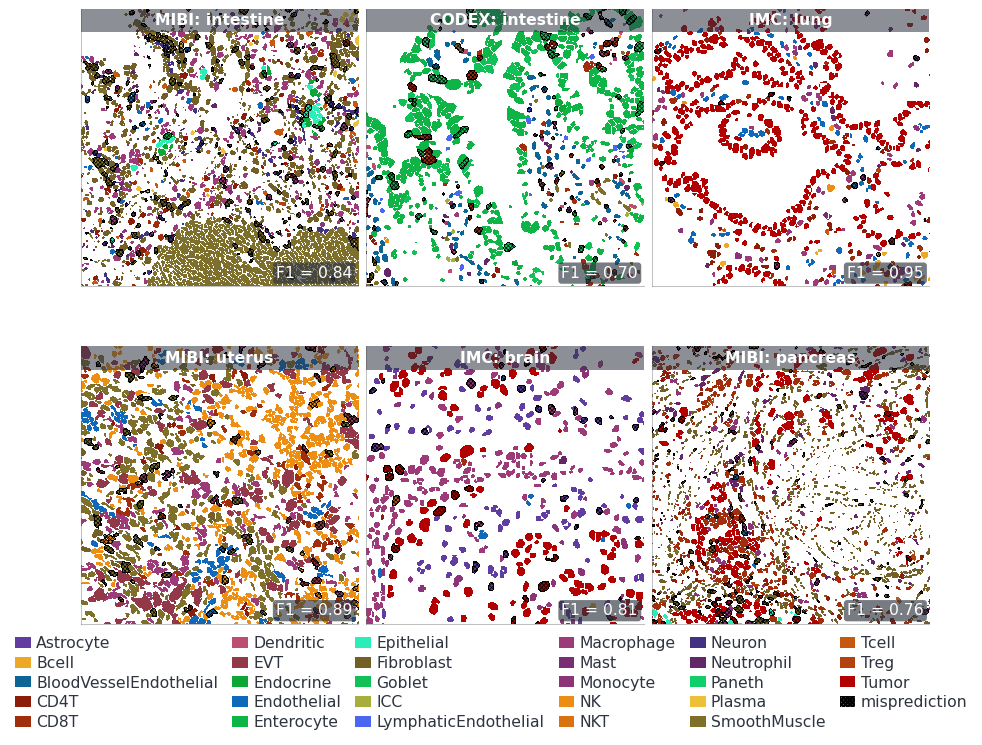

In [6]:
# --- build fov_examples (slow: loads full FOV masks) -------------------
n_rows, n_cols = 2, 3
n_panels = n_rows * n_cols
predictions_by_fov = load_predictions(TEST_PRED_CSV)
print(f'loaded predictions for {len(predictions_by_fov)} FOVs')

restrict = set(predictions_by_fov.keys())
fov_keys = select_exemplar_fovs(
    CONFIG, n=n_panels, restrict_to_keys=restrict,
    max_per_modality=3, min_cell_types=5, min_crop_entropy=1.5,
    exclude_modalities=('celldive',), exclude_tissues=('skin',),
    predictions_by_fov=predictions_by_fov)
print('picked exemplar FOVs:', fov_keys)
fov_keys = list(fov_keys)[:n_panels]

plot_h_in = COL_2 * (n_rows / n_cols); legend_strip_in = 0.95
fig, axes = plt.subplots(n_rows, n_cols,
    figsize=(COL_2, plot_h_in + legend_strip_in),
    gridspec_kw={'wspace': 0.03, 'hspace': 0.01})
narrow = is_narrow_figure(fig); axes = np.atleast_2d(axes).ravel()
zf = zarr.open(ZARR, mode='r')

crop_side = None
for k in fov_keys:
    try:
        shape = zf[k]['preprocessed/mask'].shape
        d = min(shape[0], shape[1])
        crop_side = d if crop_side is None else min(crop_side, d)
    except (KeyError, OSError):
        continue
if crop_side is None: crop_side = 1024
print(f'cropping all FOVs to {crop_side}x{crop_side} pixels')

shown_cts = set()
for i, k in enumerate(fov_keys):
    if i >= len(axes): break
    try:
        cts = _render_one(axes[i], zf, k, COLOR_MAP, crop_side=crop_side,
                          predictions=predictions_by_fov.get(k))
        shown_cts.update(cts)
    except Exception as e:
        axes[i].text(0.5, 0.5, f'{k}\n(load error: {e})', ha='center',
                     va='center', fontsize=6, color=PAL['red'],
                     transform=axes[i].transAxes)
        axes[i].set_xticks([]); axes[i].set_yticks([])
for ax in axes[len(fov_keys):]:
    ax.axis('off')

shown = sorted(shown_cts)
handles = [mpatches.Patch(facecolor=COLOR_MAP.get(c, '#A0A8B4'), label=c)
           for c in shown]
with plt.rc_context({'hatch.linewidth': 0.35}):
    handles.append(mpatches.Patch(facecolor='none', edgecolor=(0, 0, 0, 0.98),
                   hatch='xxxxxxxxxxxx', linewidth=0.0, label='misprediction'))
longest = max((len(c) for c in shown), default=8)
chip_in = (longest * 0.045) + 0.18
ncol = max(1, min(len(shown), int(COL_2 / chip_in)))
n_legend_rows = (len(shown) + ncol - 1) // ncol
leg_fontsize = 6.5 if narrow else 7.5
fig_h_in = fig.get_size_inches()[1]
legend_h_in = (n_legend_rows * (leg_fontsize / 72.0) * 1.55) + 0.18
legend_frac = min(0.40, max(0.16, legend_h_in / fig_h_in))
fig.tight_layout(rect=(0, legend_frac, 1, 0.995), w_pad=0.2, h_pad=0.0)
fig.subplots_adjust(hspace=0.01)
fig.legend(handles=handles, loc='lower center', bbox_to_anchor=(0.5, 0.005),
           frameon=False, ncol=ncol, handlelength=1.0, handletextpad=0.35,
           columnspacing=0.9, labelspacing=0.3, fontsize=leg_fontsize)
print(f'{len(fov_keys)} FOVs, {len(shown)} cell types')
plt.show()

## Workflow comparison (Sorin LUAD D119 IMC) — Supp. Fig. 8b-c

One real test-split FOV (`sorin_lung_imc_LUAD_D119`, IMC lung adenocarcinoma)
rendered three ways and compared against the archive ground truth:

- **Traditional workflow** — the canonical mean-intensity → KMeans
  overclustering (k=200) → rule-based-expert metacluster merge.
- **DeepCell Types prediction** — DeepCell Types end-to-end From Scratch predictions.
- **Ground truth** — archive `standardized_source` annotation.
- **Workflow divergence** — per-cell Jensen-Shannon divergence (k=15) between the two workflows' kNN cell-type neighborhood label distributions.

Mispredicted cells (vs GT, symmetric T-lineage hierarchy) are outlined +
cross-hatched and correctly-predicted cells dimmed toward white so errors read
first; each comparison panel carries its hierarchical macro-F1 chip. The
traditional workflow loads the **full raw channel stack** and runs KMeans, so
this section is the slowest in the notebook.

In [7]:
# --- traditional-workflow primitives (from plot_workflow_comparison_real)
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

WF_FOV = 'sorin_lung_imc_LUAD_D119'
N_CLUSTERS = 200
CROP_SIDE = 1024

def _mean_intensity_per_cell(raw, mask, channels):
    cell_ids = np.unique(mask); cell_ids = cell_ids[cell_ids != 0].astype(np.int64)
    flat_mask = mask.ravel(); n_cells = cell_ids.size; n_ch = raw.shape[0]
    means = np.zeros((n_cells, n_ch), dtype=np.float32)
    counts = np.bincount(flat_mask)
    sizes = counts[cell_ids].astype(np.float32); sizes[sizes == 0] = 1.0
    for c in range(n_ch):
        sums = np.bincount(flat_mask, weights=raw[c].ravel())
        means[:, c] = sums[cell_ids] / sizes
    return cell_ids, means

LINEAGE_RULES = [
    ('NKT',        ['CD3', 'CD56'],  [],                   []),
    ('Treg',       ['CD3', 'FoxP3'], [],                   []),
    ('CD8T',       ['CD3', 'CD8'],   [],                   []),
    ('CD4T',       ['CD3', 'CD4'],   [],                   []),
    ('Tcell',      ['CD3'],          [],                   []),
    ('Plasma',     [],               ['CD138', 'Syndecan-1', 'Syndecan1',
                                       'CD38', 'IRF4'],     ['CD3']),
    ('Bcell',      ['CD20'],         [],                   []),
    ('NK',         ['CD56'],         [],                   ['CD3']),
    ('Mast',       ['Tryptase'],     [],                   ['CD3', 'CD20']),
    ('Monocyte',   ['CD14'],         [],                   ['CD3', 'CD20', 'CD68']),
    ('Macrophage', [],               ['CD68', 'CD163'],    ['CD3', 'CD20']),
    ('Dendritic',  ['CD11c'],        [],                   ['CD3', 'CD20', 'CD68']),
    ('Neutrophil', [],               ['MPO', 'CD16'],      ['CD3', 'CD20', 'CD68']),
    ('Endothelial',['CD31'],         [],                   ['CD45']),
    ('Endothelial',[],               ['CD31', 'CD36'],     ['CD45', 'PanCK', 'CD68']),
    ('Epithelial', ['SMA'],          ['E-cadherin', 'P63'], ['CD45', 'CD31', 'Vimentin']),
    ('Epithelial', [],               ['P63', 'CK5'],       ['CD45', 'CD31', 'Vimentin']),
    ('Fibroblast', [],               ['SMA', 'Vimentin', 'COL1', 'FAP'],
                                      ['CD45', 'PanCK', 'CD31', 'E-cadherin']),
    ('Tumor',      [],               ['PanCK', 'E-cadherin', 'Beta-catenin',
                                       'CK5', 'CK6', 'CK7', 'CK17', 'HER2',
                                       'EGFR', 'p53'],      ['CD45']),
]

def _assign_cluster_label(cluster_profile, pos_thresh, neg_thresh):
    def _has(m): return m in cluster_profile.index
    for label, all_pos, any_pos, hard_neg in LINEAGE_RULES:
        all_ok = all(_has(m) and cluster_profile[m] >= pos_thresh for m in all_pos)
        any_ok = (not any_pos) or any(
            _has(m) and cluster_profile[m] >= pos_thresh for m in any_pos)
        neg_ok = all((not _has(m)) or cluster_profile[m] <= neg_thresh
                     for m in hard_neg)
        if all_ok and any_ok and neg_ok:
            return label
    return 'Unassigned'

def traditional_workflow(mean_int, channels, n_clusters, pos_thresh=0.25,
                         neg_thresh=1.0, random_state=0):
    df = pd.DataFrame(mean_int, columns=channels)
    df_t = np.arcsinh(df / 5.0)
    z = StandardScaler().fit_transform(df_t)
    k = min(n_clusters, mean_int.shape[0])
    km = KMeans(n_clusters=k, n_init=10, random_state=random_state).fit(z)
    cluster_ids = km.labels_
    cluster_profile = pd.DataFrame(z, columns=channels).groupby(cluster_ids).median()
    cluster_to_label = {c: _assign_cluster_label(profile, pos_thresh, neg_thresh)
                        for c, profile in cluster_profile.iterrows()}
    cell_labels = np.array([cluster_to_label[c] for c in cluster_ids])
    return cell_labels, cluster_ids, cluster_profile

def _cell_centroids(mask, cell_ids):
    """(row, col) pixel centroids aligned to cell_ids, on the FULL mask."""
    flat = mask.ravel()
    rr, cc = np.indices(mask.shape)
    counts = np.bincount(flat)
    counts[counts == 0] = 1
    row_sum = np.bincount(flat, weights=rr.ravel())
    col_sum = np.bincount(flat, weights=cc.ravel())
    cen = np.stack([row_sum[cell_ids] / counts[cell_ids],
                    col_sum[cell_ids] / counts[cell_ids]], axis=1)
    return cen.astype(np.float64)


In [8]:
# --- error/F1 + panel renderer (from plot_workflow_comparison_real) ----
T_LINEAGE_CHILDREN = {'CD4T', 'CD8T', 'Treg', 'NKT'}

def _hier_error_mask(pred, gt):
    has_gt = gt != 'Unassigned'; ok = pred == gt
    ok |= (gt == 'Tcell') & np.isin(pred, list(T_LINEAGE_CHILDREN))
    ok |= (pred == 'Tcell') & np.isin(gt, list(T_LINEAGE_CHILDREN))
    return has_gt & ~ok

def _hier_macro_f1(pred, gt):
    from sklearn.metrics import f1_score
    has_gt = gt != 'Unassigned'
    if not has_gt.any(): return float('nan')
    y_true = gt[has_gt]; y_pred = pred[has_gt].copy()
    collapse = (((y_true == 'Tcell') & np.isin(y_pred, list(T_LINEAGE_CHILDREN)))
                | ((y_pred == 'Tcell') & np.isin(y_true, list(T_LINEAGE_CHILDREN))))
    y_pred[collapse] = y_true[collapse]
    labels = sorted(set(y_true.tolist()))
    return float(f1_score(y_true, y_pred, labels=labels, average='macro',
                          zero_division=0))

def _draw_panel(ax, mask, cell_ids, labels, color_map, title, *,
                H, W, error_mask=None, correct_mask=None, f1=None,
                fallback_color='#BDBDBD', correct_dim_alpha=0.65):
    rgb = np.ones((H, W, 4), dtype=np.float32); by_label = {}
    for cid, lab in zip(cell_ids.tolist(), labels.tolist()):
        by_label.setdefault(str(lab), []).append(int(cid))
    for lab in (['Unassigned'] + sorted(l for l in by_label if l != 'Unassigned')):
        if lab not in by_label: continue
        ids = np.asarray(by_label[lab], dtype=mask.dtype)
        sel = np.isin(mask, ids)
        if not sel.any(): continue
        rgb[sel] = mcolors.to_rgba(color_map.get(lab, fallback_color))
    if correct_mask is not None and correct_mask.any():
        correct_cell_ids = cell_ids[correct_mask].astype(mask.dtype)
        correct_pixels = np.isin(mask, correct_cell_ids)
        if correct_pixels.any():
            rgb[correct_pixels, :3] = (rgb[correct_pixels, :3]
                * (1.0 - correct_dim_alpha) + correct_dim_alpha)
    if (mask > 0).any():
        right_diff = np.zeros_like(mask, dtype=bool); down_diff = np.zeros_like(mask, dtype=bool)
        right_diff[:, :-1] = ((mask[:, :-1] != mask[:, 1:]) & (mask[:, :-1] > 0) & (mask[:, 1:] > 0))
        down_diff[:-1, :] = ((mask[:-1, :] != mask[1:, :]) & (mask[:-1, :] > 0) & (mask[1:, :] > 0))
        rgb[right_diff | down_diff] = (1.0, 1.0, 1.0, 1.0)
    ax.imshow(rgb, interpolation='nearest', aspect='equal')
    if error_mask is not None and error_mask.any():
        draw_error_overlay(ax, mask, cell_ids[error_mask].astype(mask.dtype))
    ax.set_xticks([]); ax.set_yticks([]); ax.set_facecolor('white')
    for s in ax.spines.values():
        s.set_visible(True); s.set_color(PAL['light_gray']); s.set_linewidth(0.5)
    from matplotlib.transforms import ScaledTranslation
    fig = ax.figure
    title_off = ScaledTranslation(0, 22 / 72, fig.dpi_scale_trans)
    ax.text(0.5, 1.0, title, transform=ax.transAxes + title_off, ha='center',
            va='bottom', fontsize=7.5, fontweight='bold', color=PAL['dark'])
    if f1 is not None and not np.isnan(f1):
        ax.text(0.98, 0.02, f'F1 = {f1:.2f}', transform=ax.transAxes,
                ha='right', va='bottom', fontsize=7.5, color='white', zorder=6,
                bbox=dict(boxstyle='round,pad=0.2', facecolor='#2E3440',
                          alpha=0.65, edgecolor='none'))

In [9]:
# --- load FOV, run both workflows (slow: full raw stack + KMeans) ------
zf = zarr.open(ZARR, mode='r')
pp = zf[WF_FOV]['preprocessed']
raw = pp['raw'][:]; mask = pp['mask'][:]
channels = list(pp.attrs['channel_names'])
H, W = mask.shape
print(f'{WF_FOV}: raw {raw.shape}, mask {mask.shape}, {len(channels)} channels')

cell_ids, mean_int = _mean_intensity_per_cell(raw, mask, channels)
centroids = _cell_centroids(mask, cell_ids)  # must run before the crop below
trad_labels, cluster_ids, cluster_profile = traditional_workflow(
    mean_int, channels, n_clusters=N_CLUSTERS)
print('traditional label distribution:', Counter(trad_labels).most_common())

pred_df = pd.read_csv(TEST_PRED_CSV)
fov_rows = pred_df[pred_df['fov_name'] == WF_FOV].copy()
softmax_cols = [c for c in pred_df.columns if c in scoring.CT2IDX]
fov_rows['pred'] = fov_rows[softmax_cols].values.argmax(axis=1)
fov_rows['pred_label'] = [softmax_cols[i] for i in fov_rows['pred']]
pred_by_cell = dict(zip(fov_rows['cell_index'].astype(int), fov_rows['pred_label']))
gt_by_cell = dict(zip(fov_rows['cell_index'].astype(int), fov_rows['cell_type_actual']))
pred_labels = np.array([pred_by_cell.get(int(cid), 'Unassigned') for cid in cell_ids])
gt_labels = np.array([gt_by_cell.get(int(cid), 'Unassigned') for cid in cell_ids])

has_gt = gt_labels != 'Unassigned'
trad_err = _hier_error_mask(trad_labels, gt_labels)
pred_err = _hier_error_mask(pred_labels, gt_labels)
trad_correct = has_gt & ~trad_err; pred_correct = has_gt & ~pred_err
acc_trad = 1.0 - trad_err[has_gt].mean() if has_gt.any() else float('nan')
acc_ours = 1.0 - pred_err[has_gt].mean() if has_gt.any() else float('nan')
f1_trad = _hier_macro_f1(trad_labels, gt_labels)
f1_ours = _hier_macro_f1(pred_labels, gt_labels)
print(f'hier accuracy: traditional={acc_trad:.3f} ours={acc_ours:.3f} '
      f'(N={has_gt.sum()} cells w/ GT); macro F1: trad={f1_trad:.3f} ours={f1_ours:.3f}')

wf_color_map = dict(COLOR_MAP); wf_color_map['Unassigned'] = '#BDBDBD'

if CROP_SIDE > 0 and (H > CROP_SIDE or W > CROP_SIDE):
    annotated_ids = cell_ids[has_gt]
    density = np.isin(mask, annotated_ids) if annotated_ids.size >= 50 else (mask > 0)
    r0, c0, sh, sw = best_square_crop(density, CROP_SIDE)
    mask = mask[r0:r0 + sh, c0:c0 + sw]; H, W = mask.shape
    print(f'cropped to {sh}x{sw} at (r0,c0)=({r0},{c0})')

sorin_lung_imc_LUAD_D119: raw (17, 1998, 2008), mask (1998, 2008), 17 channels


traditional label distribution: [('Tumor', 1159), ('Unassigned', 820), ('CD4T', 549), ('Macrophage', 423), ('CD8T', 296), ('Endothelial', 272), ('Bcell', 255), ('Treg', 107), ('Monocyte', 94), ('Tcell', 57), ('Dendritic', 16), ('Neutrophil', 16)]


hier accuracy: traditional=0.761 ours=0.960 (N=3793 cells w/ GT); macro F1: trad=0.598 ours=0.934
cropped to 1024x1024 at (r0,c0)=(256,0)


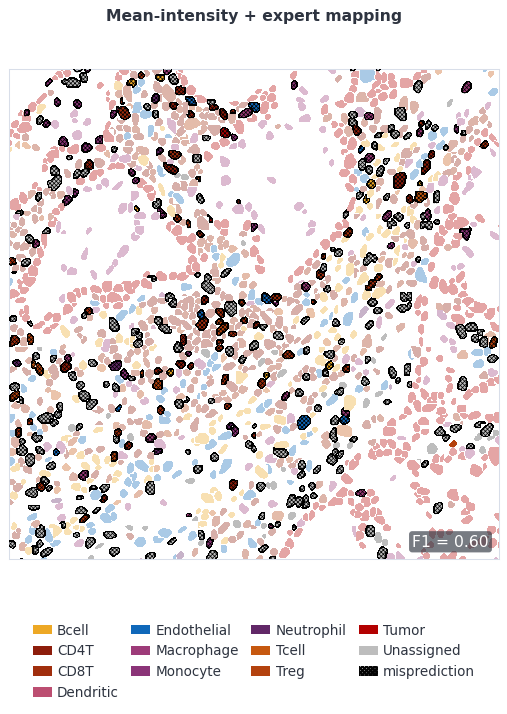

In [10]:
# --- emit the three workflow panels -----------------------------------
def _emit_workflow(title, labels, draw_kwargs, this_labels):
    panel_w = COL_1; fig_h = panel_w + 2.0
    fig, ax = plt.subplots(figsize=(panel_w, fig_h))
    _draw_panel(ax, mask, cell_ids, labels=labels, color_map=wf_color_map,
                title=title, H=H, W=W, **draw_kwargs)
    drawn = sorted(set(this_labels) - {'Unassigned'})
    if 'Unassigned' in this_labels: drawn.append('Unassigned')
    handles = [mpatches.Patch(facecolor=wf_color_map.get(l, '#BDBDBD'),
               edgecolor='none', label=l) for l in drawn]
    if 'error_mask' in draw_kwargs:
        with plt.rc_context({'hatch.linewidth': 0.35}):
            handles.append(mpatches.Patch(facecolor='none',
                edgecolor=(0, 0, 0, 0.98), hatch='xxxxxxxxxxxx',
                linewidth=0.0, label='misprediction'))
    fig.legend(handles=handles, loc='lower center', ncol=min(len(handles), 4),
               bbox_to_anchor=(0.5, 0.0), frameon=False, fontsize=FS_TICK,
               handletextpad=0.4, columnspacing=0.9)
    fig.subplots_adjust(left=0.02, right=0.98, top=1 - 0.95 / fig_h,
                        bottom=0.85 / fig_h)
    plt.show()

# fov_traditional_workflow
_emit_workflow('Mean-intensity + expert mapping',
               trad_labels,
               dict(error_mask=trad_err, correct_mask=trad_correct, f1=f1_trad),
               trad_labels)

### Traditional workflow (mean-intensity + KMeans + expert rules)

_Caption:_ Exemplar FOV (Sorin LUAD D119 IMC): mean-intensity + expert
rule-based mapping cell-type map.

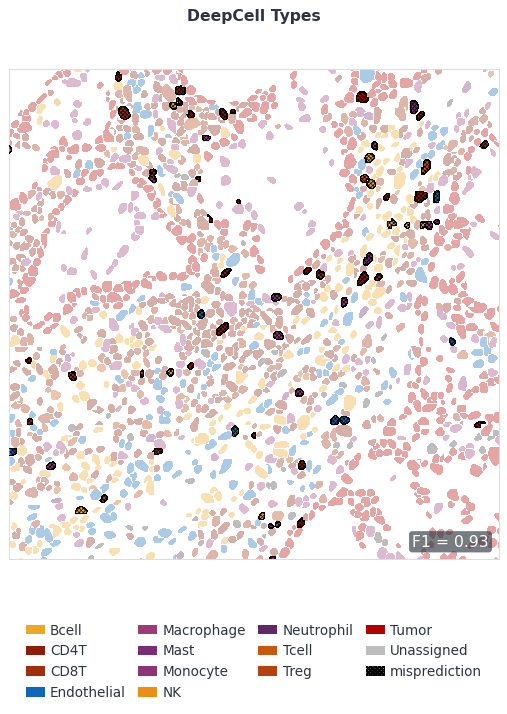

In [11]:
# fov_dct_prediction
_emit_workflow('DeepCell Types', pred_labels,
               dict(error_mask=pred_err, correct_mask=pred_correct, f1=f1_ours),
               pred_labels)

### DeepCell Types prediction

_Caption:_ Exemplar FOV (Sorin LUAD D119 IMC): DeepCell Types end-to-end
From Scratch predictions, mispredictions cross-hatched.

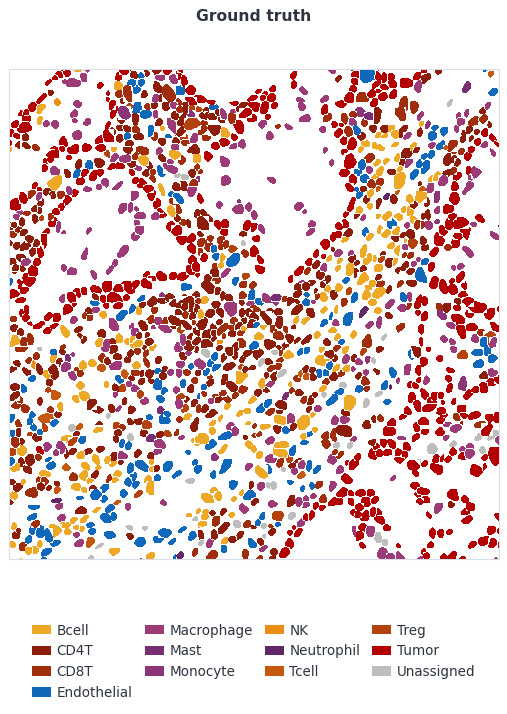

In [12]:
# fov_ground_truth
_emit_workflow('Ground truth', gt_labels,
               dict(), gt_labels)

### Ground truth

_Caption:_ Exemplar FOV (Sorin LUAD D119 IMC): ground-truth cell types from
archive standardized_source.

### Workflow divergence — Supp. Fig. 8c

_Caption:_ Exemplar FOV (Sorin LUAD D119 IMC): per-cell Jensen-Shannon
divergence (k=15) between the traditional and DeepCell Types workflows' kNN
cell-type neighborhood label distributions; chip reports T-lineage-collapsed
A-vs-B agreement and mean JSD.

cross-workflow agreement: collapsed=0.764 exact=0.752 N=3793
neighborhood JSD (k=15, base-2 bits): mean=0.145


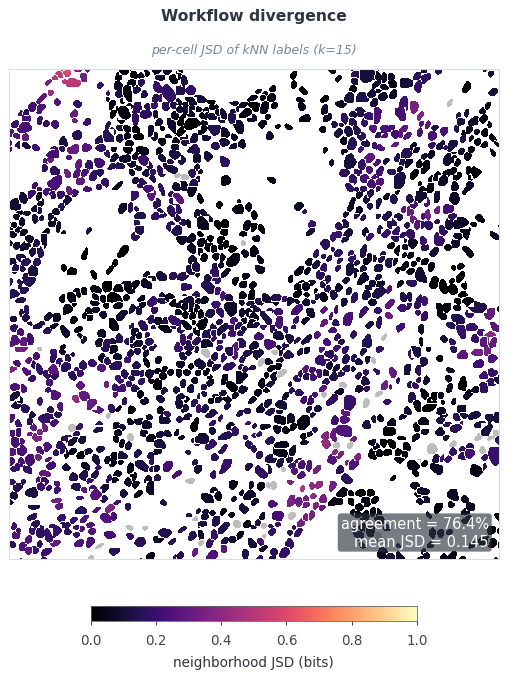

In [13]:
# fov_neighborhood_divergence — Supp. Fig. 8c
from scipy.spatial.distance import jensenshannon
from sklearn.neighbors import NearestNeighbors
import matplotlib.cm as cm
from matplotlib.colors import Normalize
from matplotlib.transforms import ScaledTranslation

KNN = 15
T_LINEAGE_CHILDREN_JSD = {'CD4T', 'CD8T', 'Treg', 'NKT'}

def _hier_collapse_pair(a, b):
    collapse = (((a == 'Tcell') & np.isin(b, list(T_LINEAGE_CHILDREN_JSD)))
                | ((b == 'Tcell') & np.isin(a, list(T_LINEAGE_CHILDREN_JSD))))
    a2, b2 = a.copy(), b.copy()
    a2[collapse] = 'Tcell'; b2[collapse] = 'Tcell'
    return a2, b2

def cross_workflow_agreement(trad_labels, pred_labels):
    comparable = pred_labels != 'Unassigned'
    if not comparable.any():
        return float('nan'), float('nan'), 0
    a = trad_labels[comparable]; b = pred_labels[comparable]
    a_c, b_c = _hier_collapse_pair(a, b)
    return float((a_c == b_c).mean()), float((a == b).mean()), int(comparable.sum())

def neighborhood_jsd(centroids, trad_labels, pred_labels, k):
    comparable = pred_labels != 'Unassigned'
    out = np.full(centroids.shape[0], np.nan, dtype=np.float64)
    idx = np.where(comparable)[0]
    if idx.size <= k:
        return out, float('nan')
    pts = centroids[idx]
    a = trad_labels[idx]; b = pred_labels[idx]
    vocab = sorted(set(a.tolist()) | set(b.tolist()))
    v2i = {lab: j for j, lab in enumerate(vocab)}
    a_i = np.array([v2i[x] for x in a]); b_i = np.array([v2i[x] for x in b])
    nn = NearestNeighbors(n_neighbors=k + 1).fit(pts)
    _, neigh = nn.kneighbors(pts)
    neigh = neigh[:, 1:]
    V = len(vocab)
    jsd = np.empty(idx.size, dtype=np.float64)
    for i in range(idx.size):
        nb = neigh[i]
        pa = np.bincount(a_i[nb], minlength=V).astype(np.float64)
        pb = np.bincount(b_i[nb], minlength=V).astype(np.float64)
        jsd[i] = jensenshannon(pa, pb, base=2) ** 2
    out[idx] = jsd
    return out, float(np.nanmean(jsd))

agree_c, agree_x, n_cmp = cross_workflow_agreement(trad_labels, pred_labels)
jsd_per_cell, jsd_mean = neighborhood_jsd(centroids, trad_labels, pred_labels, k=KNN)
print(f'cross-workflow agreement: collapsed={agree_c:.3f} exact={agree_x:.3f} N={n_cmp}')
print(f'neighborhood JSD (k={KNN}, base-2 bits): mean={jsd_mean:.3f}')

panel_w = COL_1; fig_h = panel_w + 2.0
fig, ax = plt.subplots(figsize=(panel_w, fig_h))
vmax = float(np.nanmax(jsd_per_cell)) if np.isfinite(jsd_per_cell).any() else 1.0
vmax = max(vmax, 1e-6)
norm = Normalize(vmin=0.0, vmax=vmax)
cmap = plt.get_cmap('magma')

rgb = np.ones((H, W, 4), dtype=np.float32)
nan_ids = cell_ids[~np.isfinite(jsd_per_cell)].astype(mask.dtype)
if nan_ids.size:
    sel = np.isin(mask, nan_ids)
    rgb[sel] = mcolors.to_rgba('#BDBDBD')
finite = np.isfinite(jsd_per_cell)
for cid, v in zip(cell_ids[finite].tolist(), jsd_per_cell[finite].tolist()):
    sel = mask == cid
    if sel.any():
        rgb[sel] = cmap(norm(v))
if (mask > 0).any():
    right = np.zeros_like(mask, dtype=bool); down = np.zeros_like(mask, dtype=bool)
    right[:, :-1] = ((mask[:, :-1] != mask[:, 1:]) & (mask[:, :-1] > 0) & (mask[:, 1:] > 0))
    down[:-1, :] = ((mask[:-1, :] != mask[1:, :]) & (mask[:-1, :] > 0) & (mask[1:, :] > 0))
    rgb[right | down] = (1.0, 1.0, 1.0, 1.0)

ax.imshow(rgb, interpolation='nearest', aspect='equal')
ax.set_xticks([]); ax.set_yticks([]); ax.set_facecolor('white')
for s in ax.spines.values():
    s.set_visible(True); s.set_color(PAL['light_gray']); s.set_linewidth(0.5)
title_off = ScaledTranslation(0, 22 / 72, fig.dpi_scale_trans)
sub_off = ScaledTranslation(0, 6 / 72, fig.dpi_scale_trans)
ax.text(0.5, 1.0, 'Workflow divergence', transform=ax.transAxes + title_off,
        ha='center', va='bottom', fontsize=7.5, fontweight='bold', color=PAL['dark'])
ax.text(0.5, 1.0, f'per-cell JSD of kNN labels (k={KNN})',
        transform=ax.transAxes + sub_off, ha='center', va='bottom',
        fontsize=6.0, color=PAL['gray'], style='italic')
ax.text(0.98, 0.02, f'agreement = {100 * agree_c:.1f}%\nmean JSD = {jsd_mean:.3f}',
        transform=ax.transAxes, ha='right', va='bottom', fontsize=7.0,
        color='white', zorder=6,
        bbox=dict(boxstyle='round,pad=0.2', facecolor='#2E3440', alpha=0.65, edgecolor='none'))
sm = cm.ScalarMappable(norm=norm, cmap=cmap); sm.set_array([])
cax = fig.add_axes([0.18, 0.6 / fig_h, 0.64, 0.10 / fig_h])
cb = fig.colorbar(sm, cax=cax, orientation='horizontal')
cb.ax.tick_params(labelsize=FS_TICK, length=2)
cb.set_label('neighborhood JSD (bits)', fontsize=FS_TICK)
cb.outline.set_linewidth(0.4)
fig.subplots_adjust(left=0.02, right=0.98, top=1 - 0.95 / fig_h, bottom=0.85 / fig_h)
plt.show()
